In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("loan_approval_data.csv")

In [8]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Handle missing values

In [9]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["float64"]).columns

In [13]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = "mean")
cat_imp = SimpleImputer(strategy = "most_frequent")

df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [17]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Exploratory Data Analysis (EDA)

Text(0.5, 1.0, 'Is the loan approved?')

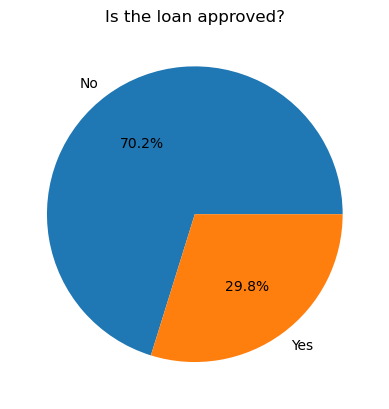

In [20]:
# How balance our data are?

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels = ["No", "Yes"], autopct = "%1.1f%%")
plt.title("Is the loan approved?")


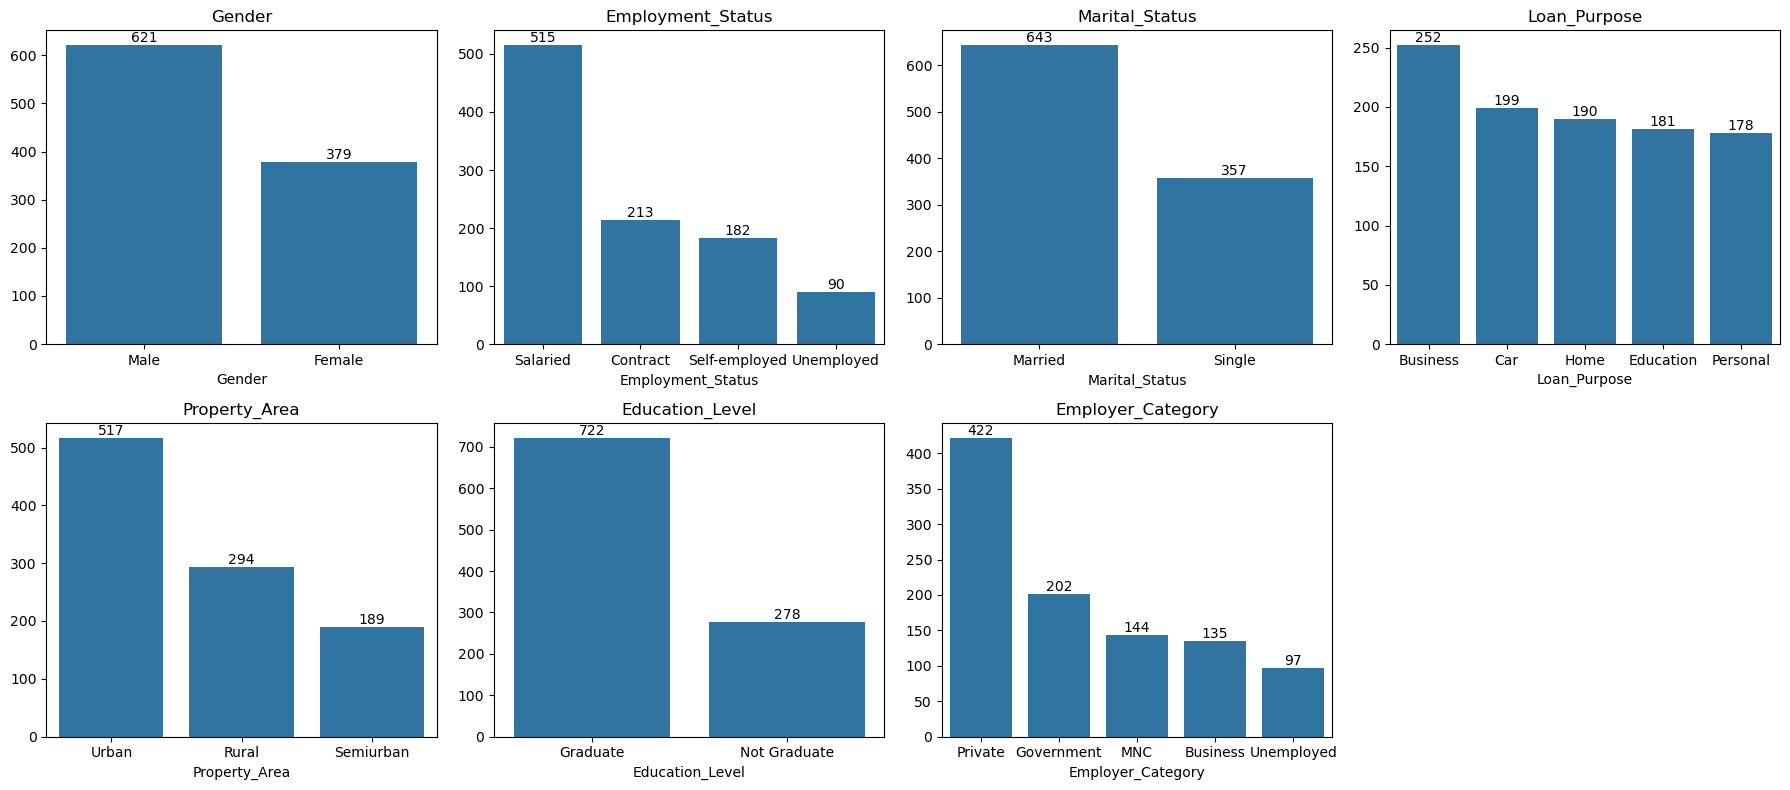

In [35]:
# Analyse categorical features

fig, axes = plt.subplots(2, 4, figsize = (18, 8))
axes = axes.flatten()

columns = [
    "Gender",
    "Employment_Status",
    "Marital_Status",
    "Loan_Purpose",
    "Property_Area",
    "Education_Level",
    "Employer_Category"
]

for i, col in enumerate(columns):
    count = df[col].value_counts()

    ax = sns.barplot(
        x = count.index,
        y = count.values,
        ax = axes[i]
    )

    axes[i].set_title(col)
    ax.bar_label(ax.containers[0])

fig.delaxes(axes[7])  # delete the unused space
plt.tight_layout()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

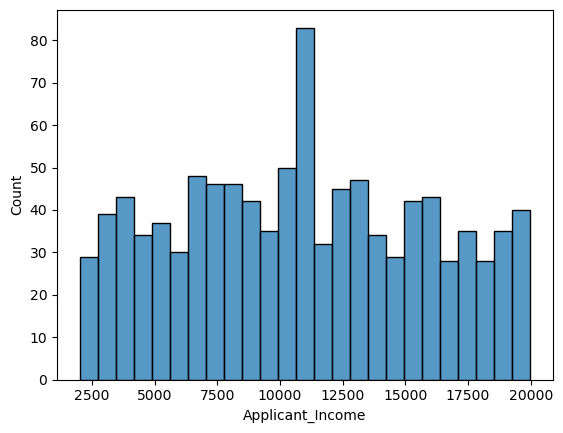

In [36]:
# Analyze applicant income
sns.histplot(
    data = df, 
    x = "Applicant_Income",
    bins = 25
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

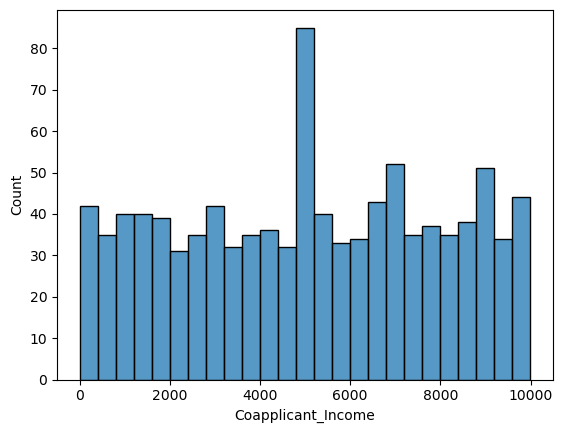

In [37]:
# Analyze co-applicant income
sns.histplot(
    data = df, 
    x = "Coapplicant_Income",
    bins = 25
)

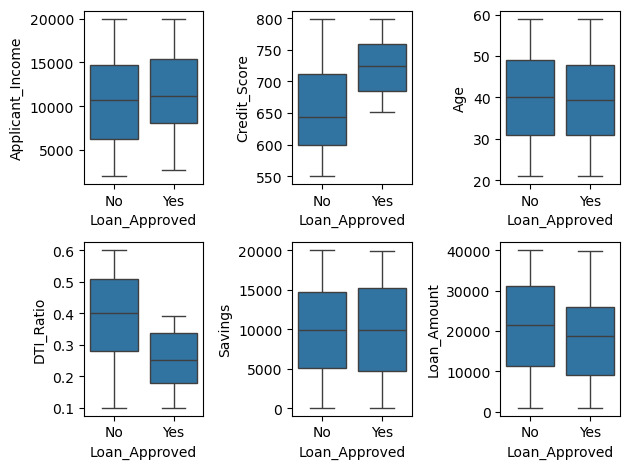

In [42]:
# Outliers detection using box plots
fig, axes = plt.subplots(2, 3)


sns.boxplot(ax = axes[0, 0], data = df, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax = axes[0, 1], data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = axes[0, 2], data = df, x = "Loan_Approved", y = "Age")
sns.boxplot(ax = axes[1, 0], data = df, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax = axes[1, 1], data = df, x = "Loan_Approved", y = "Savings")
sns.boxplot(ax = axes[1, 2], data = df, x = "Loan_Approved", y = "Loan_Amount")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

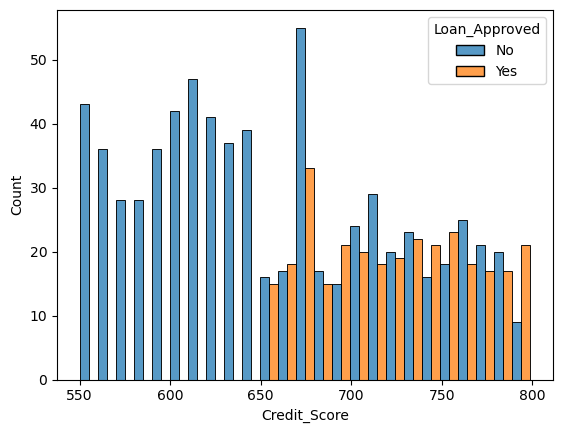

In [45]:
# Credit Score for Loan Approval
sns.histplot(
    data = df, 
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 25,
    multiple = "dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

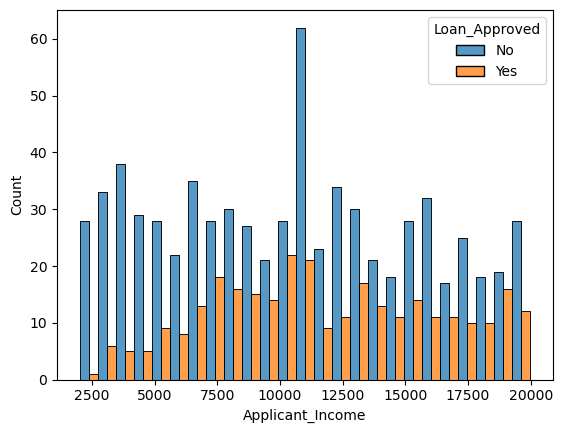

In [47]:
sns.histplot(
    data = df, 
    x = "Applicant_Income",
    hue = "Loan_Approved",
    bins = 25,
    multiple = "dodge"
)

In [48]:
# Remove the applicant id as it has no impact on loan approval
df = df.drop("Applicant_ID", axis = 1)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Feature Encoding

In [50]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [52]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [63]:
# One hot encoding
ohe = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")

cols = ["Marital_Status", "Employment_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols), index = df.index)

df = pd.concat([df.drop(columns = cols), encoded_df], axis = 1)

In [65]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmaps

<Axes: >

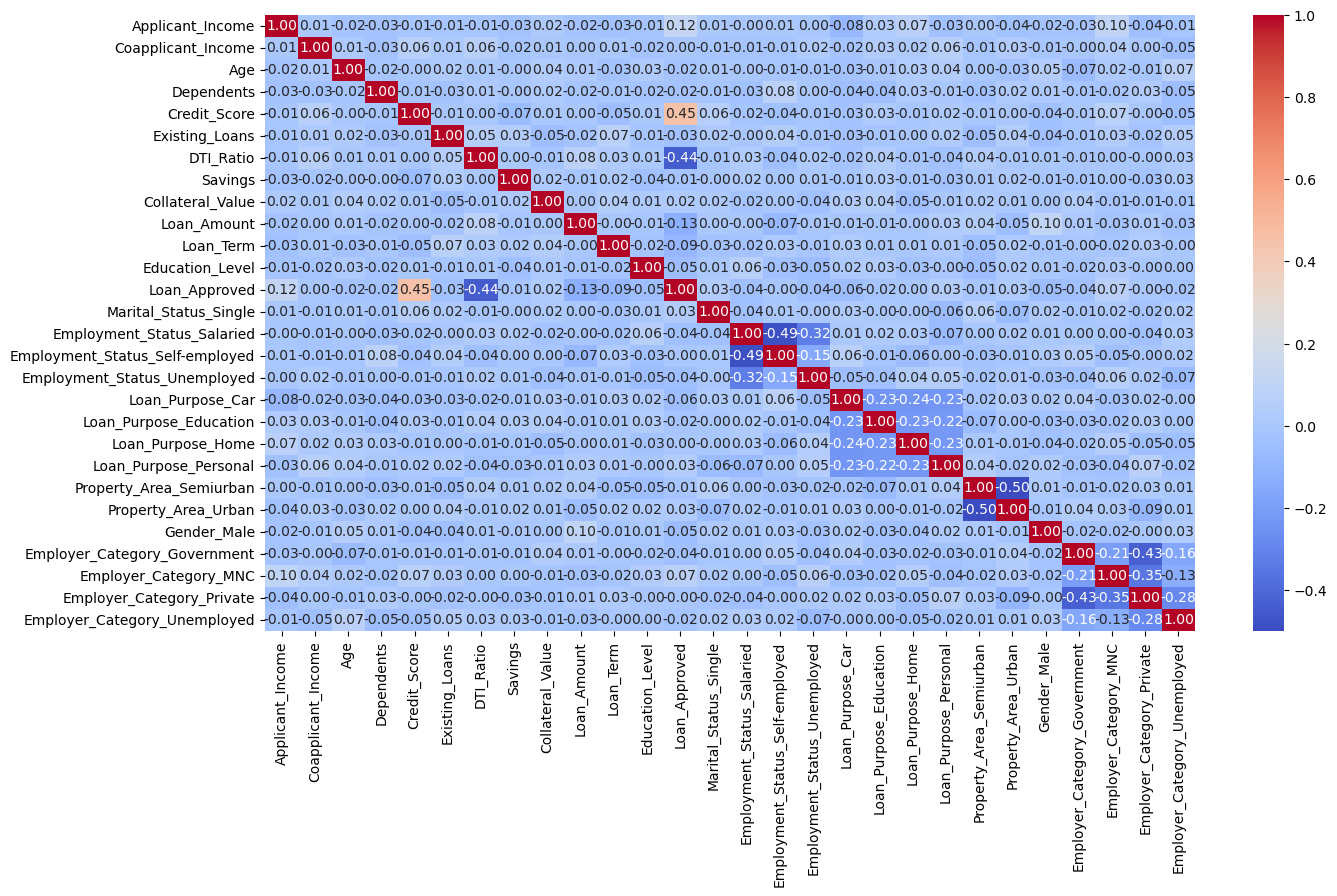

In [70]:
numeric_cols = df.select_dtypes(include = "number")
corr_matrix = numeric_cols.corr()

plt.figure(figsize = (15, 8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [68]:
corr_matrix["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Train_Test_Split + Feature Scaling

In [72]:
X = df.drop("Loan_Approved", axis = 1)
y = df["Loan_Approved"]

In [75]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 27))

# Model Training and Evaluation

In [82]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

# Evaluation 
print("LOGISTIC REGRESSION")
print(f"Precision : {precision_score(y_test, y_pred)}")
print(f"Recall : {recall_score(y_test, y_pred)}")
print(f"F1 Score : {f1_score(y_test, y_pred)}")
print(f"Accuracy : {accuracy_score(y_test, y_pred)}") 
print(f"Confusion Matrix : \n{confusion_matrix(y_test, y_pred)}") 

LOGISTIC REGRESSION
Precision : 0.7833333333333333
Recall : 0.7704918032786885
F1 Score : 0.7768595041322314
Accuracy : 0.865
Confusion Matrix : 
[[126  13]
 [ 14  47]]


In [88]:
# kNN Model
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 5)

knn_model.fit(X_train_scaled, y_train)
y_pred2 = knn_model.predict(X_test_scaled)

# Evaluation 
print("kNN Model")
print(f"Precision : {precision_score(y_test, y_pred2)}")
print(f"Recall : {recall_score(y_test, y_pred2)}")
print(f"F1 Score : {f1_score(y_test, y_pred2)}")
print(f"Accuracy : {accuracy_score(y_test, y_pred2)}") 
print(f"Confusion Matrix : \n{confusion_matrix(y_test, y_pred2)}") 

kNN Model
Precision : 0.6274509803921569
Recall : 0.5245901639344263
F1 Score : 0.5714285714285714
Accuracy : 0.76
Confusion Matrix : 
[[120  19]
 [ 29  32]]


In [89]:
# Naive Bayes 
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)
y_pred3 = nb_model.predict(X_test_scaled)

# Evaluation 
print("Naive Bayes Model")
print(f"Precision : {precision_score(y_test, y_pred3)}")
print(f"Recall : {recall_score(y_test, y_pred3)}")
print(f"F1 Score : {f1_score(y_test, y_pred3)}")
print(f"Accuracy : {accuracy_score(y_test, y_pred3)}") 
print(f"Confusion Matrix : \n{confusion_matrix(y_test, y_pred3)}") 

Naive Bayes Model
Precision : 0.8035714285714286
Recall : 0.7377049180327869
F1 Score : 0.7692307692307693
Accuracy : 0.865
Confusion Matrix : 
[[128  11]
 [ 16  45]]


# Best model for now based on precision => Naive Bayes

# Feature Engineering

In [99]:
# Add or transform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_Log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns = ["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

# Train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

# Evaluation 
print("LOGISTIC REGRESSION")
print(f"Precision : {precision_score(y_test, y_pred)}")
print(f"Recall : {recall_score(y_test, y_pred)}")
print(f"F1 Score : {f1_score(y_test, y_pred)}")
print(f"Accuracy : {accuracy_score(y_test, y_pred)}") 
print(f"Confusion Matrix : \n{confusion_matrix(y_test, y_pred)}") 

LOGISTIC REGRESSION
Precision : 0.7846153846153846
Recall : 0.8360655737704918
F1 Score : 0.8095238095238095
Accuracy : 0.88
Confusion Matrix : 
[[125  14]
 [ 10  51]]


In [101]:
# kNN Model
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 5)

knn_model.fit(X_train_scaled, y_train)
y_pred2 = knn_model.predict(X_test_scaled)

# Evaluation 
print("kNN Model")
print(f"Precision : {precision_score(y_test, y_pred2)}")
print(f"Recall : {recall_score(y_test, y_pred2)}")
print(f"F1 Score : {f1_score(y_test, y_pred2)}")
print(f"Accuracy : {accuracy_score(y_test, y_pred2)}") 
print(f"Confusion Matrix : \n{confusion_matrix(y_test, y_pred2)}") 

kNN Model
Precision : 0.6730769230769231
Recall : 0.5737704918032787
F1 Score : 0.6194690265486725
Accuracy : 0.785
Confusion Matrix : 
[[122  17]
 [ 26  35]]


In [102]:
# Naive Bayes 
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)
y_pred3 = nb_model.predict(X_test_scaled)

# Evaluation 
print("Naive Bayes Model")
print(f"Precision : {precision_score(y_test, y_pred3)}")
print(f"Recall : {recall_score(y_test, y_pred3)}")
print(f"F1 Score : {f1_score(y_test, y_pred3)}")
print(f"Accuracy : {accuracy_score(y_test, y_pred3)}") 
print(f"Confusion Matrix : \n{confusion_matrix(y_test, y_pred3)}") 

Naive Bayes Model
Precision : 0.8113207547169812
Recall : 0.7049180327868853
F1 Score : 0.7543859649122807
Accuracy : 0.86
Confusion Matrix : 
[[129  10]
 [ 18  43]]
